Milestone 3: Neural Network Designs

In [3]:
import tensorflow as tf
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from pathlib import Path
from time import strftime
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)

def get_run_logdir(root_logdir='my_logs'):
    return Path(root_logdir)/strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))


def create_baseline(meta):
    X_shape_ = meta["X_shape_"]
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(300, activation="relu", input_shape=(X_shape_[1],)),
        tf.keras.layers.Dense(300, activation="relu"),
        tf.keras.layers.Dense(4, activation="softmax")
    ])
    model.compile(optimizer="adam", 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model


In [4]:
clf = KerasClassifier(model=create_baseline, epochs=50, batch_size=32, verbose=1)

In [5]:
import numpy as np
from sklearn.svm import LinearSVC
data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [6]:
train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

In [7]:
from utils import flattener
from sklearn.preprocessing import MinMaxScaler

pipe_baseline = Pipeline([
    ("Flatten", flattener),
    ("Scale", MinMaxScaler()),
    ("model", clf)
])

In [8]:
from utils import train_eval_model
from utils import stratified_subset

x_tr, y_tr = stratified_subset(train_images, train_labels, 22000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)


In [12]:

acc_baseline, prec_baseline, recall_baseline = train_eval_model(
    name="Baseline ANN",
    model=pipe_baseline,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5673 - loss: 1.0576
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6336 - loss: 0.9452
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6607 - loss: 0.8918
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6824 - loss: 0.8432
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7032 - loss: 0.7979
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7187 - loss: 0.7552
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7303 - loss: 0.7251
Epoch 8/50
564/688 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7395 - loss: 0.7091

KeyboardInterrupt: 

To absolutely no ones suprise even the completely untuned most baseline neural network possible sort of destroyed all other models.

In [9]:
from utils import median, avg_2x2_pool, flatten_data
from sklearn.preprocessing import FunctionTransformer

In [ ]:


preprocess_nn = Pipeline([
    ("median", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])

acc_prep, prec_prep, recall_prep = train_eval_model(
    name="avg+median filtering results",
    model=preprocess_nn,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

Epoch 1/50


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5717 - loss: 1.0484
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6330 - loss: 0.9430
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6543 - loss: 0.9056
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6719 - loss: 0.8684
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6831 - loss: 0.8464
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6934 - loss: 0.8200
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6990 - loss: 0.8050
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7096 - loss: 0.7858
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7147 - loss: 0.7715
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7171 - loss: 0.7624
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7244 - loss: 0.7458
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy

Performed Worse than on just the raw training data.

In [8]:
avg_nn = Pipeline([
    ("avg14", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])


acc_avc, prec_avg, recall_avg = train_eval_model(
    name="avg filtering results",
    model=avg_nn,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    callbacks=[tensorboard_cb, early_stopping_cb]
)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

Epoch 1/50


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5790 - loss: 1.0375
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6402 - loss: 0.9337
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6619 - loss: 0.8856
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6787 - loss: 0.8455
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6991 - loss: 0.8062
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7062 - loss: 0.7846
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7164 - loss: 0.7594
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7282 - loss: 0.7346
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7313 - loss: 0.7204
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7376 - loss: 0.7080
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7468 - loss: 0.6902
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

Once again overall a worse performance. Preprocessing appears to be a possible detriment for this.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Baseline", "Median + avg", "Avg"]
accuracy =  [acc_baseline, acc_prep, acc_avc]  # replace with your values
precision = [prec_baseline, prec_prep, prec_avg]
recall =    [recall_baseline, recall_prep, recall_avg]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, accuracy, width, label="Accuracy")
ax.bar(x, precision, width, label="Precision")
ax.bar(x + width, recall, width, label="Recall")

ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

NameError: name 'acc_baseline' is not defined

All perfrom roughly similar with a slight edge to no preprocessing at this moment.

In [10]:
label_names = {
    0: "Normal",
    1: "Choroidal neovascularization",
    2: "Diabetic macular edema",
    3: "Drusen"
}



Now lets test results on a wide and deep network. The goal of a wide and deep network is to both hopefully learn simple patterns that can be learned just from the input data. As well as complex patterns that can be learned from the deep path too.

In [13]:
def create_wide_and_deep(meta):
    '''Creates the wide & deep network.
    deep network is designed to be same as pervious networks
    so we can guage if the width actually adds anything to the network.
    '''
    X_shape = meta["X_shape_"]
    print(X_shape)

    inputs= tf.keras.layers.Input(shape=(X_shape[1],))

    hidden_layer_1 = tf.keras.layers.Dense(300, activation='relu')(inputs)
    hidden_layer_2 = tf.keras.layers.Dense(300, activation='relu')(hidden_layer_1)

    concat_layer = tf.keras.layers.Concatenate()([inputs, hidden_layer_2])
    output_layer = tf.keras.layers.Dense(4, activation="softmax")(concat_layer)

    
    model = tf.keras.Model(inputs=inputs, outputs=output_layer)

    model.compile(optimizer="adam", 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model

clf_wide = KerasClassifier(model=create_wide_and_deep, epochs=50, batch_size=32, verbose=1)

pipe_baseline_wide = Pipeline([
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

In [13]:
train_eval_model(
    name="Wide & Deep baseline model",
    model=pipe_baseline_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

(22000, 784)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5762 - loss: 1.0506
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6434 - loss: 0.9309
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6723 - loss: 0.8722
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6939 - loss: 0.8173
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7101 - loss: 0.7744
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7258 - loss: 0.7362
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7389 - loss: 0.7047
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7485 - loss: 0.6854
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7595 - loss: 0.6594
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7657 - loss: 0.6420
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7739 - loss: 0.6252
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

(0.78, 0.7708492201706331, 0.78)

Very consistent results but nothing incredible.

In [14]:
pipe_avg_wide = Pipeline([
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

train_eval_model(
    name="Wide & Deep baseline model",
    model=pipe_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)


(22000, 196)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5805 - loss: 1.0352
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6397 - loss: 0.9311
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6697 - loss: 0.8756
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6844 - loss: 0.8396
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6993 - loss: 0.8041
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7125 - loss: 0.7722
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7208 - loss: 0.7499
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7284 - loss: 0.7339
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7370 - loss: 0.7133
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7435 - loss: 0.6935
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7492 - loss: 0.6793
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

(0.7835, 0.7603010312216563, 0.7835)

Best Accuracy So Far, but lower precision

In [15]:
pipe_med_avg_wide = Pipeline([
    ("med", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

train_eval_model(
    name="Wide & Deep Median + Avg model",
    model=pipe_med_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

(22000, 196)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5798 - loss: 1.0440
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6320 - loss: 0.9469
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6536 - loss: 0.9067
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6684 - loss: 0.8735
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6785 - loss: 0.8483
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6891 - loss: 0.8251
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6976 - loss: 0.8070
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7065 - loss: 0.7912
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7071 - loss: 0.7800
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7165 - loss: 0.7650
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7220 - loss: 0.7464
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

(0.757, 0.7293605314125037, 0.757)

In [14]:
def create_wide_and_deep_subsample(meta, wide_frac=0.5, deep_frac=0.5, seed=42):
    X_shape_ = meta["X_shape_"]
    n_features = X_shape_[1]

    rng = np.random.RandomState(seed)
    wide_idx = rng.choice(n_features, size=int(n_features * wide_frac), replace=False)
    deep_idx = rng.choice(n_features, size=int(n_features * deep_frac), replace=False)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    wide_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, wide_idx, axis=1))(inputs)
    deep_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, deep_idx, axis=1))(inputs)

    # Deep path
    deep = tf.keras.layers.Dense(300, activation="relu")(deep_input)
    deep = tf.keras.layers.Dense(300, activation="relu")(deep)

    # Concatenate
    concat = tf.keras.layers.Concatenate()([wide_input, deep])

    output = tf.keras.layers.Dense(4, activation="softmax")(concat)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
    )
    return model

clf_wide_subsample = KerasClassifier(model=create_wide_and_deep_subsample, epochs=50, batch_size=32, verbose=1)

pipe_wide_subsample_base = Pipeline([
    ("flat", flattener),
    ("scale", MinMaxScaler()),
    ("model", clf_wide_subsample)
])

train_eval_model(
    name="Wide & Deep with feature subsampling",
    model=pipe_wide_subsample_base,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)


Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5714 - loss: 1.0527
Epoch 2/50
291/688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6190 - loss: 0.9739

KeyboardInterrupt: 

The wide and deep model performed slightly better than the baseline model. Interestingly there seems to be a percision recall trade off between averaging for this case. When averaging to reduce dimensionality the precision dropped but the recall increased. I would interpret this as the model sort of being more 'certain' or 'aggressive' in it's guessing leading to more total positive cases captured on average per class but also less overall accuracy on those guesses. Ultimately we should take both these into consideration especially when acknowledging that our models are tuned for Accuracy (Marco Recall).

Let us now look towards tuning an existing model and observe the results there. First we will explore general ideas in model architecture. Number of layers, number of neurons, learning rate, and basic optimimizer choices. This can help us get more insight into what kind of model architectures are doing well for this problem.

In [11]:
import keras_tuner as kt

def build_tuned_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    avg = hp.Choice("avg", values=[True, False])
    pool = hp.Int("pool_size", min_value=2, max_value=4)
    activation = hp.Choice("activation", values=["relu", "leaky_relu", "elu", "selu"])
    batch_norm = hp.Choice("batch_norm", values=[True, False])
    decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)

    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    else:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )

    model = tf.keras.Sequential()

    if avg:
        model.add(tf.keras.layers.Reshape((28, 28, 1))) #Added because 4d data is expected for average pooling
        model.add(tf.keras.layers.AveragePooling2D(pool_size=(pool, pool)))

    model.add(tf.keras.layers.Rescaling(scale=1.0 / 255)) #Our MinMaxScaler in tensorflow format

    model.add(tf.keras.layers.Flatten())

    dropout_rate = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)

    for i in range(n_hidden):
        n_neurons = hp.Int(f"n_neurons{i}", min_value=16, max_value=256)
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
        if batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(4, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

This is a pretty deep tuning search. so lets break it down.
1. This allows us first and formost give a general idea of what model architecture is preferred (deep path vs shallow, wide layers vs small layers)
2. Control our preprocessing step through the averaging choice.
3. Have a preliminary search over activation functions & optimizers
4. Introduce batch normalization & dropout rate if it is beneficial.

In [27]:
tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=50,
    directory="tuning_results",
    project_name="my_rnd_search",
)

tuner.search(
    x_tr, y_tr,
    epochs=50,
    validation_data=(x_va, y_va),
    callbacks=[
        early_stopping_cb,
        tensorboard_cb
    ]
)

Trial 50 Complete [00h 00m 49s]
val_accuracy: 0.49300000071525574

Best val_accuracy So Far: 0.7944999933242798
Total elapsed time: 15h 11m 10s


Interesting! an extremely deep network is preferred. With a range of 100-200 per network. Batch normalization is preferred. Averaging is not required. We are using Batch Normalization and have a decay rate of around .97

Some notes after looking in Tensorboard:
1. Activation Function has no clear winner even after looking at ~10 best models.
2. Similarly averaging doesn't seem to have that big of a difference. The absolute best performed well without it though.
3. Batch norm performed best on the best models, but also had a fairly large split.
4. Higher decay rate seems (mostly preferred)
5. Dropout of zero is MOST LIKELY BEST. biggest indicator so far.

Everything else had a fairly large spread. Lets assume a lower dropout rate and try a different tuning method and see if we can gain more info. Since Selu Won last time we are going to try introducion a norm layer to see if that combo with selu and batch norm can get us somewhere.

this inital search was quite flawed. We respectfully ask you don't consider it when grading, it is being included so you can still observe thought process and progression.

Reasons it was flawed:
1. Selu was used without normalization layer (stupid mistake)
2. learning rate wasn't kept constant (MASSIVE MISTAKE). because of this a potentially great model could have performed poorly due to having too high a learning rate or too low a learning rate. Keeping it consistent is ideal, but even better is putting measures in place to make sure learning rate is less of a factor.
3. The inclusion of preprocessing screening may muddle the search for an ideal model. Averaging twice could drop performance of an otherwise good model by a lot. this muddles our search for truly well architectured model.
4. No sample weights were used.

In [22]:
len(x_tr) // 32

687

In [12]:
from utils import flatten_data

def build_tuned_wide_and_deep(hp, meta, mean, variance, seed=42):
    X_shape = meta["X_shape_"]
    n_features = X_shape[1]

    activation = hp.Choice("activation", values=["relu", "leaky_relu", "elu", "selu"])
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    #learning_rate = hp.Choice("learning_rate", values=[3e-4, 1e-3])
    #optimizer = hp.Choice("optimizer", values=["sgd", "adam"]) #Just adam for now
    batch_norm = hp.Boolean("batch_norm")
    #decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)
    wide_and_deep = hp.Boolean("wide_and_deep")
    if wide_and_deep:
        wide_frac = hp.Float("wide_frac", min_value=.7, max_value=1)
        deep_frac = hp.Float("deep_frac", min_value=.7, max_value=1)
        rng = np.random.RandomState(seed)
        wide_idx = rng.choice(n_features, size=int(n_features * wide_frac), replace=False)
        deep_idx = rng.choice(n_features, size=int(n_features * deep_frac), replace=False)
    else:
        deep_idx = np.arange(0, n_features)
    '''
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    '''
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=3e-3,
        decay_steps=687 * 50,
        warmup_target=3e-3,
        warmup_steps=687 * 2,  # 2 epochs of warmup
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    if activation == "selu":
        norm_layer = tf.keras.layers.Normalization(mean=mean, variance=variance)
        preprocessing = norm_layer(inputs)
    else:
        preprocessing = tf.keras.layers.Rescaling(1./255)(inputs)
    
    if wide_and_deep:
        wide_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, wide_idx, axis=1))(preprocessing)

    deep_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, deep_idx, axis=1))(preprocessing)

    last_layer = deep_input
    for i in range(n_hidden):
        n_neurons = hp.Int(f"n_neurons{i}", min_value=16, max_value=256)
        last_layer = tf.keras.layers.Dense(n_neurons, activation=activation)(last_layer)
        if batch_norm:
            last_layer = tf.keras.layers.BatchNormalization()(last_layer)
    
    if wide_and_deep:
        last_layer = tf.keras.layers.Concatenate()([last_layer, wide_input])

    outputs = tf.keras.layers.Dense(4, activation="softmax")(last_layer)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

class MyTuningModel(kt.HyperModel):
    def __init__(self, meta, x_tr):
        super().__init__()
        self.meta = meta
        norm_layer = tf.keras.layers.Normalization()
        norm_layer.adapt(x_tr)
        self.mean_, self.var_ = norm_layer.get_weights()[0], norm_layer.get_weights()[1] #getting our mean and var incase we use selu


    def fit(self, hp, model, X, y, **kwargs):
        '''
        if hp.Boolean("median"):
            X = median(X)
        if hp.Boolean("avg"):
            X = avg_2x2_pool(X)

        '''

        X = flatten_data(X)

        return model.fit(X, y, **kwargs)
    
    def build(self, hp):
        return build_tuned_wide_and_deep(hp, self.meta, mean=self.mean_, variance=self.var_)
        




To briefly explain my rationale. My goal here is to build an overal architecture that works well. Things like number of layers, whether or not to use wide and deep, number of nodes per layer, activation function, things that have a wide sweeping impact on the overall model is what we are titrating for right now. Because of this some ideas that I was originally going to include have been commented out as they may muddy my original objective. I experienced a little bit of "Search Creep" when making this where I just kept adding more and more to the search and felt like my net was cast too wide, so we have cut back to what we need. Maybe most critical difference from the first search: The learning rate is being constrained. This parameter controls too much of performance so it was opted to be constrained. Sample weights are also being introduced as we want to make sure the model generalizes well to all classes, a decision that in hindsight should've been made long ago

In [13]:
run_logdir = get_run_logdir('my_logs/architecture_search')

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)
sample_weights_valid = compute_sample_weight(class_weight="balanced", y=y_va)

tensorboard_cb =  tf.keras.callbacks.TensorBoard(run_logdir)
#profile batching is removed (the callback was taken from the textbook)
#profile batching just collects data on general performance metrics
#such as how long something takes on the CPU
#or which layer is the slowests
#since our hyperparameters are changing constantly this info isn't very useful.



It's time to go into more detail on Tuner Selection. Looking at documentation there is really 4 choices:
1. RandomSearch
2. GridSearch
3. BayesianOptimization
4. Hyperband

GridSearch is by far the easiest to rule out we are searching over so many parameters it would just be impossible to scan over all of them. Especially when we are dealing with continuous variables.
Random Search vs Hyperband is a tougher choice. Hyperband could essentially be viewed as a 'smarter' Random Search. However this search will be done for a WHILE. and because of this we are able to be far more forgiving on what Hyperband tends to explore while still maintaining the cost cutting benefits of it. So in actuality this should lead to just more raw models being explored.
Finally we have Bayesian optimization: The problem here is in structure versus execution. Bayesian optimization assumes a function:
 f(hyperparemeters) -> Loss/Val_accuracy/accuracy that we can model. Essentially something like given these datapoints probability that our function looks like this is. and then probes new points smartly based around where in the feature space we know is good and where is unknown. The problem with this is the inital assumption. Bayesian optimization assumes that if you have mostly similar hyperparameters you will get mostly a similar results. And this is simply not the case with our design, because we have Booleans. If we used a boolean for wide and deep for example and it was true and had a deep layer of 2, we might wrongly explore that the feature space with deep layers of 2 for action space of two and generalize this architectures where it doesn't belong like a non wide and deep model. The reality is our model is certianly not continuous in nature. something as simple as chaning wide & deep can mean massive changes for what is optimal for the other hyperparameters, the feature space is likely jagged and rough. This is an exaggeration of the problem, in practice BayesianOptimization would probably still work well, but perhaps not the best. 

In [14]:
x_tr_flat = flatten_data(x_tr)
x_va_flat = flatten_data(x_va) 
#flattening so preprocessing runs smoothly

meta = {"X_shape_": (x_tr_flat.shape[0], x_tr_flat.shape[1])} #Necessary to give the model and idea of input shape
#already preflatted so logic stayes the same

print("x_tr_flat shape:", x_tr_flat.shape)
print("x_va_flat shape:", x_va_flat.shape)
print("meta:", meta)
print("sample_weights shape:", sample_weights.shape)
print("sample_weights_valid shape:", sample_weights_valid.shape)

x_tr_flat shape: (22000, 784)
x_va_flat shape: (2000, 784)
meta: {'X_shape_': (22000, 784)}
sample_weights shape: (22000,)
sample_weights_valid shape: (2000,)


The idea behind this is that: A poor architecture model will still perform a good architecture model with a learning rate that causes diveragence or too low training. Our solution to this is twofold: One we will use a learning_rate schedule. A learning rate schedule modifies the learning rate as training goes on to solve this very problem. We will use Cosine Decay with a warm up. We will start out with a higher learning rate so slower models can catch up quickly then quickly peel back as we aproach optimal solutions. Secondly we will use the above callback. if training is not improving from the aggressive start it will begin lowering the learning rate in hopes that it will peel back in time.

I plan on letting this run overnight so we'll see the results in the morning. I am not too concerned with training time because of this.

In [ ]:
tuner = kt.Hyperband(
    hypermodel=MyTuningModel(meta=meta, x_tr=x_tr_flat),
    objective="val_accuracy",
    max_epochs=75,
    factor=2,
    hyperband_iterations=3,
    directory="./hyperband_dir",
    project_name="Architecture_tuning",
    overwrite=False,
    seed=42
    )

tuner.search(
    x_tr_flat, 
    y_tr,
    validation_data=(x_va_flat, y_va, sample_weights_valid),
    sample_weight=sample_weights,
    batch_size=32,
    callbacks=[early_stopping_cb, tensorboard_cb],
    verbose=1
)

Trial 1077 Complete [00h 01m 35s]
val_accuracy: 0.7080000042915344

Best val_accuracy So Far: 0.7770000100135803
Total elapsed time: 09h 32m 18s


1076 Different Neural Network Architectures built and tested lets see the results. I am running into a very annoying problem. I now have too much data for my laptop to open with Tensorboard. My laptop is literally crashing as I try to open it. And I can't upload it to the github as that is too intensive for my laptop as well.

In [15]:
import keras_tuner as kt

tuner = kt.Hyperband(
    hypermodel=MyTuningModel(meta=meta, x_tr=x_tr_flat),
    objective="val_accuracy",
    max_epochs=75,
    factor=2,
    hyperband_iterations=3,
    directory="./hyperband_dir",
    project_name="Architecture_tuning",
    overwrite=False,
    seed=42,
)

Reloading Tuner from ./hyperband_dir\Architecture_tuning\tuner0.json


Had to reload as my laptop crashed trying to access tensorboard.

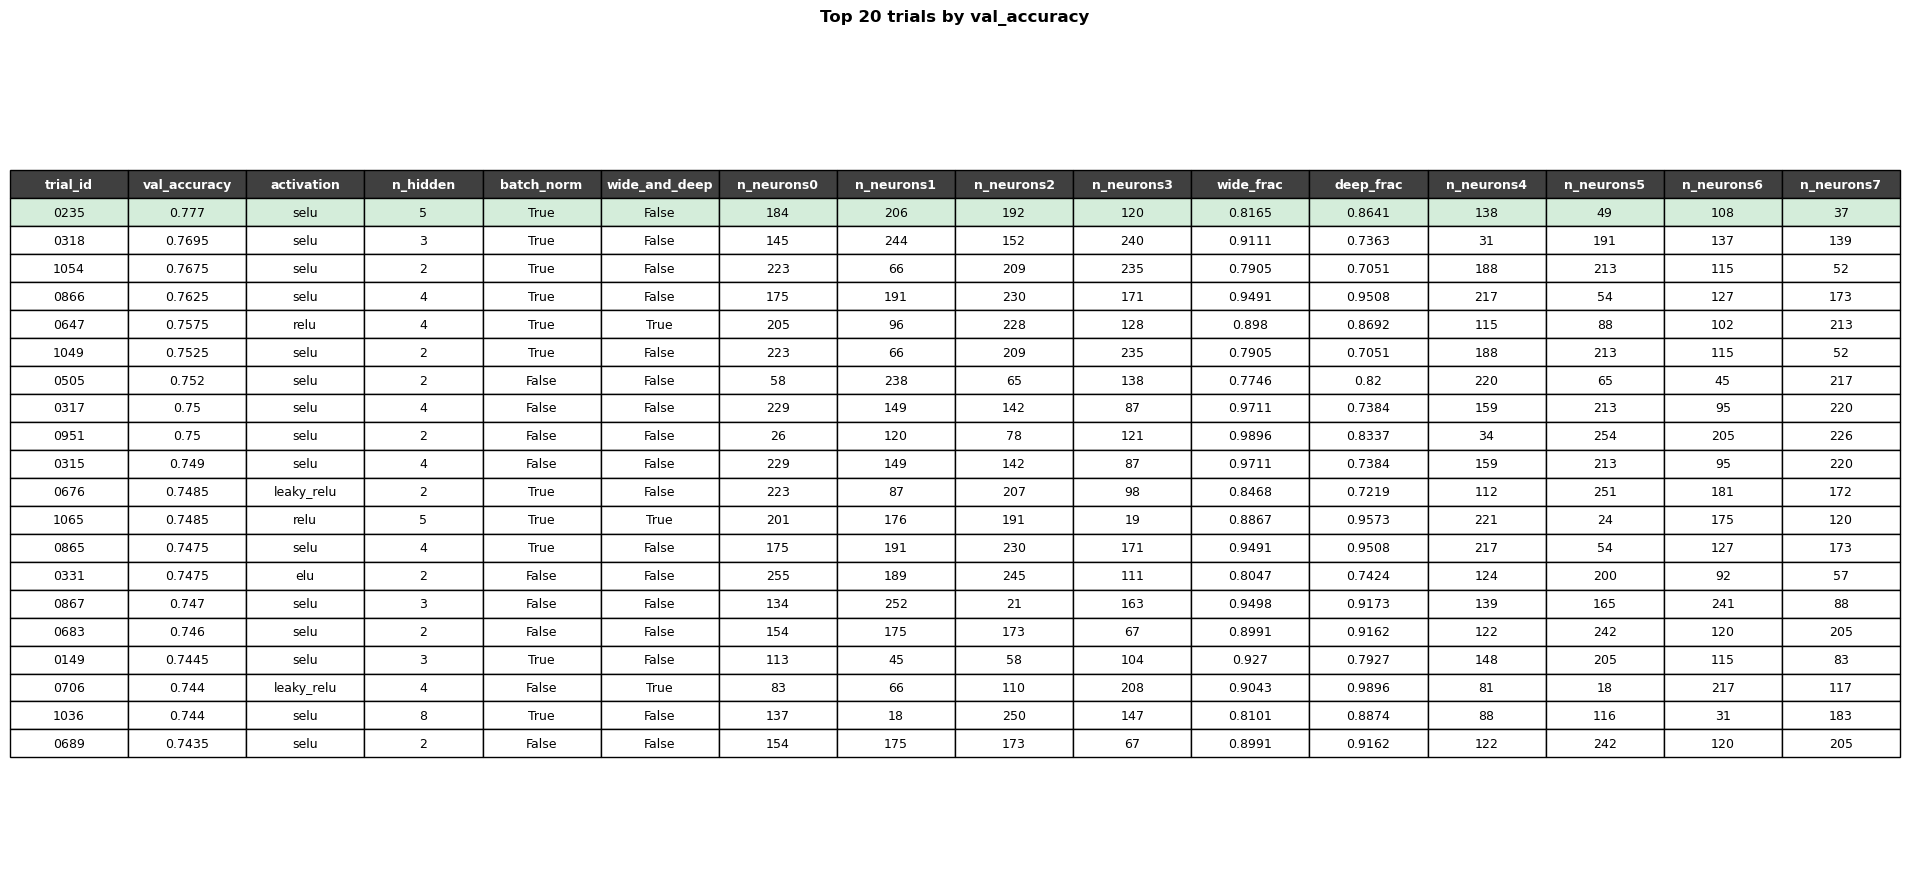

In [26]:
import matplotlib.pyplot as plt
import pandas as pd


trials = tuner.oracle.get_best_trials(num_trials=100)
rows = []
for trial in trials:
    row = {"trial_id": trial.trial_id, "val_accuracy": trial.score}
    row.update(trial.hyperparameters.values)
    rows.append(row)
df = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False).reset_index(drop=True)


# Figure 1: top 20 trials as a table
top20 = df.head(20).copy()

# Drop columns that aren't useful in the display (keep if you want them)
cols_to_show = [c for c in top20.columns if c not in {"tuner/trial_id", "tuner/epochs", "tuner/initial_epoch", "tuner/bracket", "tuner/round"}]
top20_display = top20[cols_to_show]

# Round floats for readability
for col in top20_display.select_dtypes(include="float").columns:
    top20_display[col] = top20_display[col].round(4)

fig, ax = plt.subplots(figsize=(max(12, len(cols_to_show) * 1.2), len(top20_display) * 0.4 + 1))
ax.axis("off")
table = ax.table(
    cellText=top20_display.values,
    colLabels=top20_display.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Bold the header row
for j in range(len(top20_display.columns)):
    cell = table[0, j]
    cell.set_text_props(weight="bold")
    cell.set_facecolor("#404040")
    cell.set_text_props(color="white")

# Highlight the best row
for j in range(len(top20_display.columns)):
    table[1, j].set_facecolor("#d4edda")

ax.set_title("Top 20 trials by val_accuracy", pad=20, fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig("top20_trials.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Some notes here: Of the activations Selu is definitely the majority.
n_hidden varies quite a lot. seems to mostly be constrainted in the 2-4 range though. (shallower networks).
Batch norm has quite the mix. This makes sense as Selu is a replacement for BatchNorm.
Wide & Deep is majority False.
Neuron count should maybe have been held constant across layers. Hard to interperet, however there is often a slight dip in neuron count in the models last layer.

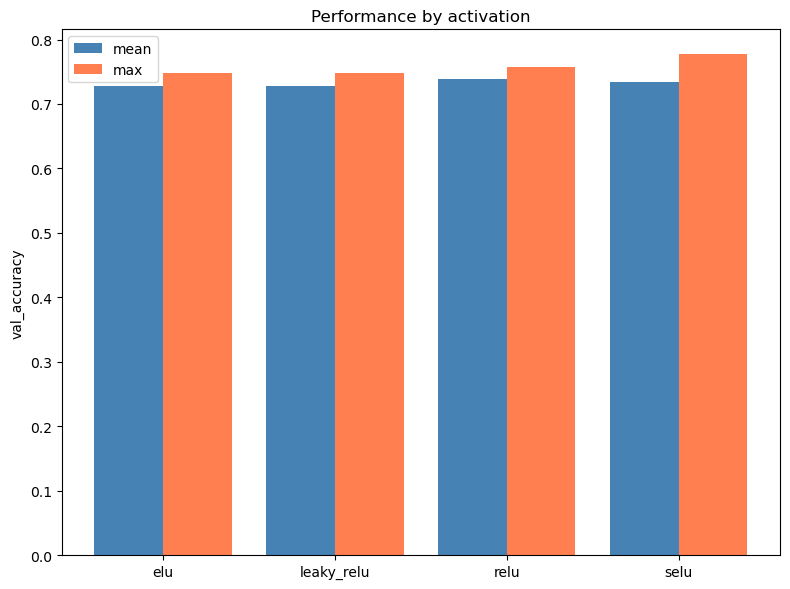

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
activation_stats = df.groupby("activation")["val_accuracy"].agg(["mean", "max"])
x = range(len(activation_stats))
ax.bar([i - 0.2 for i in x], activation_stats["mean"], width=0.4, label="mean", color="steelblue")
ax.bar([i + 0.2 for i in x], activation_stats["max"], width=0.4, label="max", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(activation_stats.index)
ax.set_ylabel("val_accuracy")
ax.set_title("Performance by activation")
ax.legend()
plt.tight_layout()
plt.savefig("activation_performance.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

While their averages are roungly the same selu has a much higher peak.

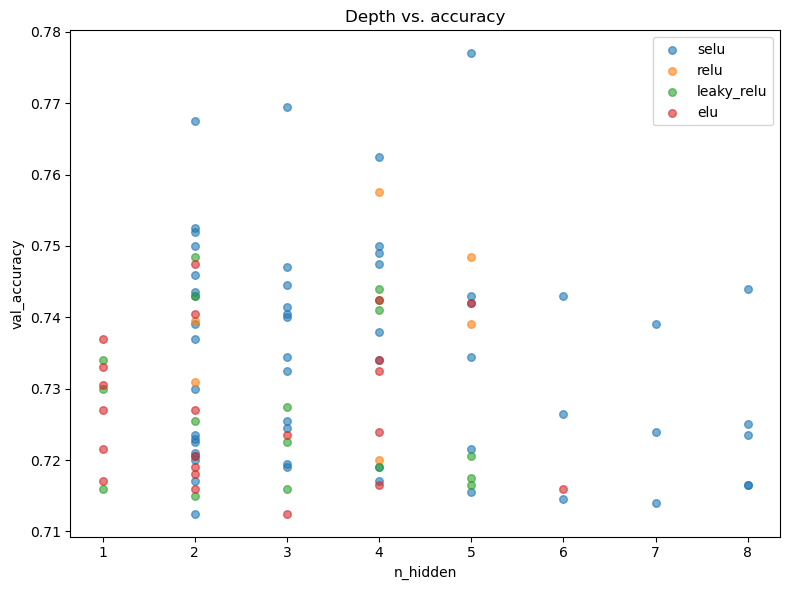

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
for activation in df["activation"].unique():
    subset = df[df["activation"] == activation]
    ax.scatter(subset["n_hidden"], subset["val_accuracy"],
               label=activation, alpha=0.6, s=30)
ax.set_xlabel("n_hidden")
ax.set_ylabel("val_accuracy")
ax.set_title("Depth vs. accuracy")
ax.legend()
plt.tight_layout()
plt.savefig("depth_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Generally Selu is performing the best once again. specifically on deeper models. too. the best accuracy for each layer except 1 is Selu.

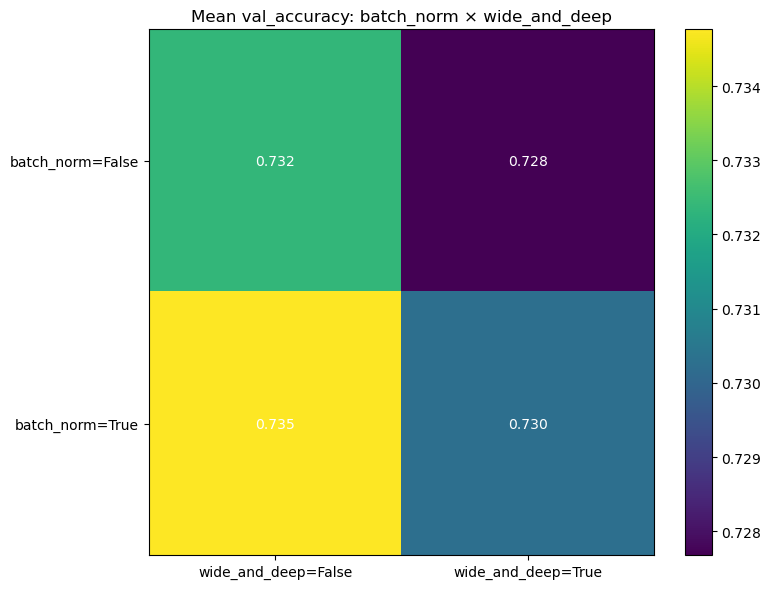

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
pivot = df.pivot_table(values="val_accuracy", index="batch_norm",
                      columns="wide_and_deep", aggfunc="mean")
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"wide_and_deep={c}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"batch_norm={i}" for i in pivot.index])
ax.set_title("Mean val_accuracy: batch_norm × wide_and_deep")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}",
                ha="center", va="center", color="white")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("batchnorm_widedeep_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Models on average perform best when batch norm is true and wide and deep is false. Theory Time: Wide and deep is not helping input too much. especially when subsetting. Batch normalization or Selu is a substitution seems almost essential for the model though.

A worry though: selu could be advantaged because of normalized inputs and not because of actual improvement. To see lets build a relu 

In [27]:
def build_test_relu(meta, mean, variance, seed=42):
    X_shape = meta["X_shape_"]
    n_features = X_shape[1]

    activation = "relu"
    n_hidden = 5
    #learning_rate = hp.Choice("learning_rate", values=[3e-4, 1e-3])
    #optimizer = hp.Choice("optimizer", values=["sgd", "adam"]) #Just adam for now
    batch_norm = True
    #decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)
    wide_and_deep = False
    '''
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    '''
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=3e-3,
        decay_steps=687 * 50,
        warmup_target=3e-3,
        warmup_steps=687 * 2,  # 2 epochs of warmup
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    norm_layer = tf.keras.layers.Normalization(mean=mean, variance=variance)
    preprocessing = norm_layer(inputs)


    last_layer = preprocessing
    for i in range(n_hidden):
        n_neurons = 200
        last_layer = tf.keras.layers.Dense(n_neurons, activation=activation)(last_layer)
        if batch_norm:
            last_layer = tf.keras.layers.BatchNormalization()(last_layer)

    outputs = tf.keras.layers.Dense(4, activation="softmax")(last_layer)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(x_tr_flat)
mean_, var_ = norm_layer.get_weights()[0], norm_layer.get_weights()[1]

model = build_test_relu(meta=meta, mean=mean_, variance=var_)


In [29]:
model.fit(
    x_tr_flat,
    y_tr,
    validation_data=(x_va_flat, y_va, sample_weights_valid),
    sample_weight=sample_weights,
    epochs=75,
    callbacks=[early_stopping_cb]
)

Epoch 1/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4078 - loss: 1.3354 - val_accuracy: 0.4980 - val_loss: 1.1667
Epoch 2/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5005 - loss: 1.1521 - val_accuracy: 0.6310 - val_loss: 1.0551
Epoch 3/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5417 - loss: 1.0688 - val_accuracy: 0.5940 - val_loss: 1.0399
Epoch 4/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5629 - loss: 1.0199 - val_accuracy: 0.5475 - val_loss: 1.0699
Epoch 5/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5819 - loss: 0.9749 - val_accuracy: 0.5580 - val_loss: 1.0324
Epoch 6/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5965 - loss: 0.9466 - val_accuracy: 0.6170 - val_loss: 0.9221
Epoch 7/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6142 - loss: 0.9076 - val_accuracy: 0.6540 - val_loss: 0.9421
Epoch 8/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6300 - loss: 0.8771 - val_accuracy:

Val Accuracy is siginificantly lower. for this model than our best from the search. This suggest that SELU could actually be viable.

In [30]:
x_tr.shape

(22000, 28, 28)

Lets now explore the last thing we watch to test out. a convolutional network.

In [35]:
from functools import partial

DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")

model = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

model.compile(
    optimizer="adam"

)

run_logdir = get_run_logdir('my_logs/CNN')

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
x_tr_4d = x_tr[:, :, :, np.newaxis]

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=3e-3,
        decay_steps=687 * 75,
        warmup_target=3e-3,
        warmup_steps=687 * 2,  # 2 epochs of warmup
    )

optimizer = tf.keras.optimizers.Adam(lr_schedule)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.fit(
    x_tr,
    y_tr,
    validation_data=(x_va, y_va, sample_weights_valid),
    sample_weight=sample_weights,
    epochs=75,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

Epoch 1/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.2772 - loss: 4.5359 - val_accuracy: 0.4190 - val_loss: 1.3488
Epoch 2/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.4723 - loss: 1.3051 - val_accuracy: 0.4340 - val_loss: 1.1607
Epoch 3/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.5254 - loss: 1.2203 - val_accuracy: 0.5090 - val_loss: 1.2321
Epoch 4/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 55s 80ms/step - accuracy: 0.5393 - loss: 1.1848 - val_accuracy: 0.6410 - val_loss: 1.0689
Epoch 5/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 56s 81ms/step - accuracy: 0.4727 - loss: 1.2513 - val_accuracy: 0.1475 - val_loss: 1.3174
Epoch 6/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.5105 - loss: 1.2031 - val_accuracy: 0.6665 - val_loss: 1.1478
Epoch 7/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.5502 - loss: 1.1712 - val_accuracy: 0.3485 - val_loss: 1.1298
Epoch 8/75
688/688 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.5206 - loss: 1.1871 - 